# Feynman's ratchet

The potential of the ratchet looks like periodic function composed of linear segments, for example

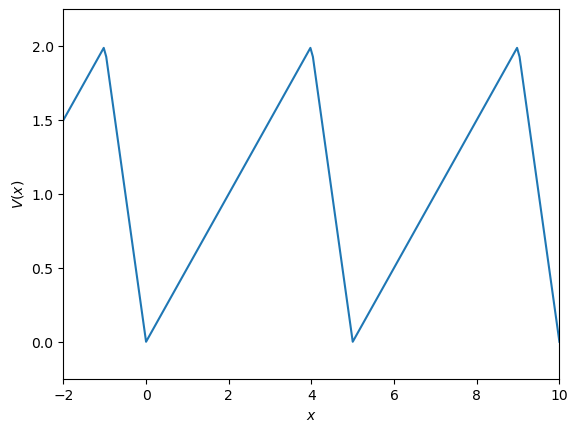

In [13]:
import numpy as np
import matplotlib.pyplot as plt

x0 = 5
x1 = 4
a = 2

def U(x):
    phase = x % x0
    cond = (phase >= 0) & (phase <= x1)
    return np.where(cond, a*phase/x1, a-a*(phase-x1)/(x0-x1))

x = np.linspace(-5,10,250)
ux = np.empty_like(x)
for i in range(len(ux)):
    ux[i] = U(x[i])

fig, ax = plt.subplots(1,1)
ax.set(xlabel=r"$x$", ylabel=r"$V(x)$", xlim=[-2,10], ylim=[-0.25,2.25])
ax.plot(x, ux)

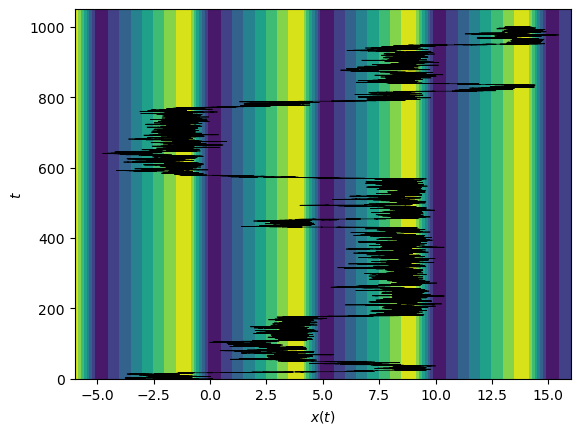

In [21]:
from LSolver import SimulationConfig, underdamped

def F(x):
    phase = x % x0
    cond = (phase >= 0) & (phase <= x1)
    return np.where(cond, a/x1, - a/(x0-x1))

beta = 1.0
T = 1/beta
gma = 2.0

cfg = SimulationConfig(
    gamma = gma,
    F_func = lambda t,x,y: F(x),
    Tx_func = lambda t,x,y: T,
    Ty_func = lambda t,x,y: T,
    t_max = 1000.0,
    dt = 0.001
)

fig, ax = plt.subplots(1,1)

[X, Y] = np.meshgrid(np.linspace(-6.0,16.0,150),np.linspace(0,1050,150))
Z = U(X)

ax.contourf(X,Y,Z)

rng = np.random.default_rng(seed = 42)

data = underdamped(cfg, rng = rng)[0]

ax.set(xlabel = r"$x(t)$", ylabel = r"$t$")
ax.plot(data, cfg.t_array, color = "black", linewidth=0.5)

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:46<00:00, 21.48it/s]


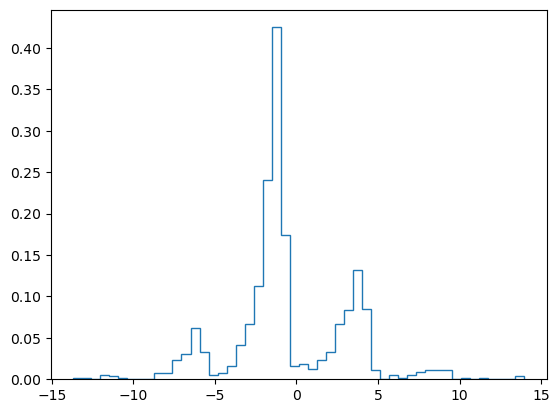

In [25]:
from tqdm import tqdm

N = 1000
rng = np.random.default_rng(seed=2048)

cfg = SimulationConfig(
    gamma = gma,
    F_func = lambda t,x,y: F(x),
    Tx_func = lambda t,x,y: T,
    Ty_func = lambda t,x,y: T,
    t_max = 30.0,
    dt = 0.005
)

data = np.empty(shape=(N,len(cfg.t_array)))

for m in tqdm(range(N)):
    data[m] = underdamped(cfg, rng=rng)[0]

fig, ax = plt.subplots(1,1)
counts, bins = np.histogram(data[:,-1],density = True, bins=50)
ax.stairs(counts, bins)